# Overview

In [397]:
import pandas as pd

df = pd.read_csv("../data/train.csv").drop('id', axis=1)
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...
58640,34,120000,MORTGAGE,5.0,EDUCATION,D,25000,15.95,0.21,Y,10,0
58641,28,28800,RENT,0.0,MEDICAL,C,10000,12.73,0.35,N,8,1
58642,23,44000,RENT,7.0,EDUCATION,D,6800,16.00,0.15,N,2,1
58643,22,30000,RENT,2.0,EDUCATION,A,5000,8.90,0.17,N,3,0


In [398]:
accepted_percentage = (df['loan_status'].sum() / len(df)) * 100
print(f"Accepted loan percentage: {accepted_percentage:.2f}%")
df.dtypes

Accepted loan percentage: 14.24%


person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
loan_status                     int64
dtype: object

# Features analysis

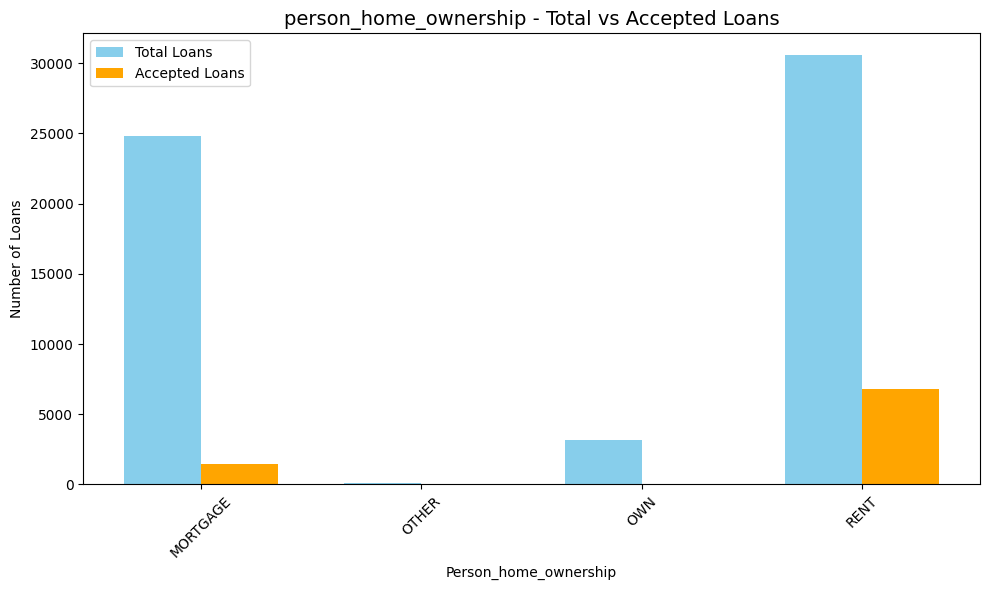

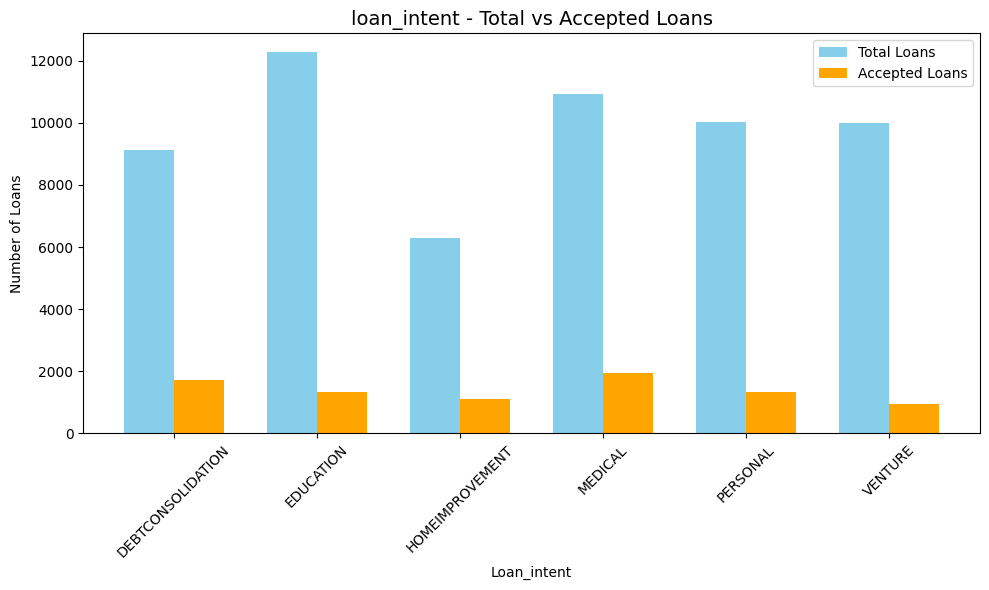

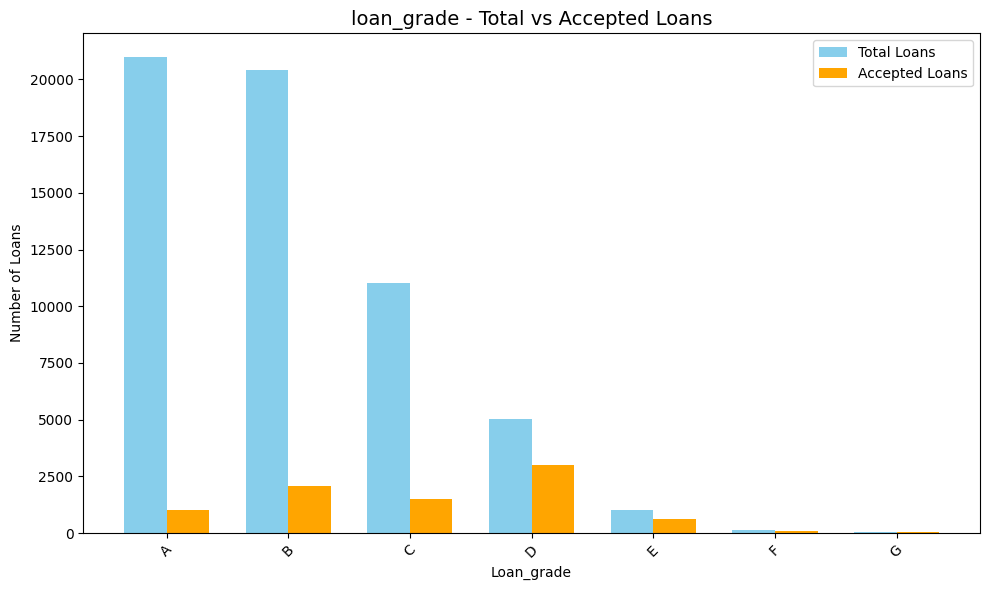

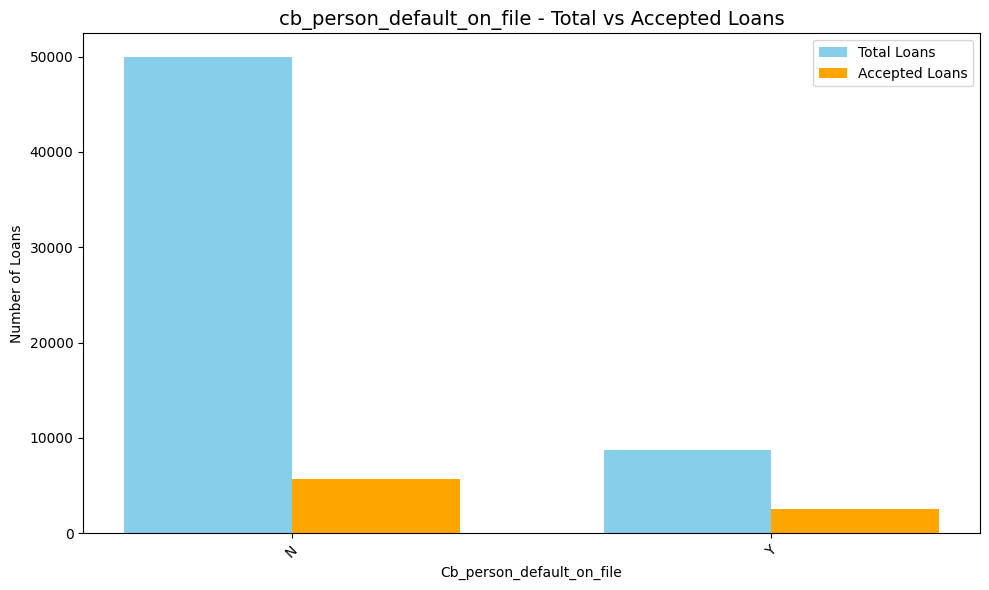

In [399]:
import matplotlib.pyplot as plt
import numpy as np

def plot_categorical_bar(df, column, title=None):
    """
    Plots a grouped bar chart for a categorical column:
    - Total loans per category
    - Accepted loans per category

    Args:
        df (pd.DataFrame): The input DataFrame.
        column (str): The categorical column to visualize.
        title (str, optional): Custom chart title.
    """
    # Total and accepted loan counts per category
    total_counts = df[column].value_counts().sort_index()
    accepted_counts = df[df['loan_status'] == True][column].value_counts().sort_index()

    # Align indices to ensure matching categories
    categories = sorted(total_counts.index)
    total = [total_counts.get(cat, 0) for cat in categories]
    accepted = [accepted_counts.get(cat, 0) for cat in categories]

    x = np.arange(len(categories))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    bars1 = ax.bar(x - width/2, total, width, label='Total Loans', color='skyblue')
    bars2 = ax.bar(x + width/2, accepted, width, label='Accepted Loans', color='orange')

    # Labels and formatting
    ax.set_ylabel('Number of Loans')
    ax.set_xlabel(column.capitalize())
    ax.set_title(title or f'{column} - Total vs Accepted Loans', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=45)
    ax.legend()

    plt.tight_layout()
    plt.show()

# Apply to all object-type columns
for col in df.columns:
    if df[col].dtype == object:
        plot_categorical_bar(df, col)


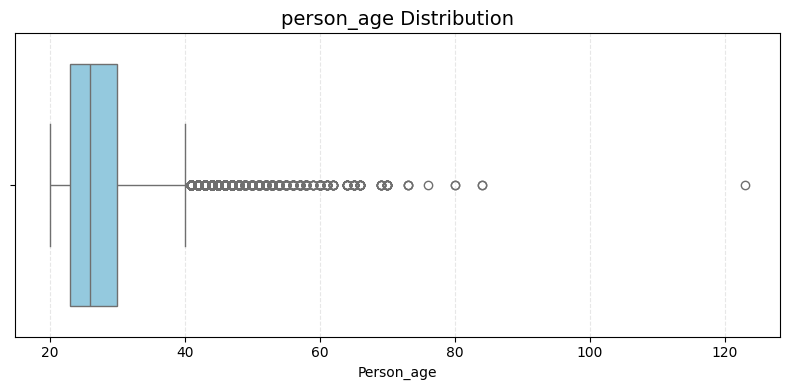

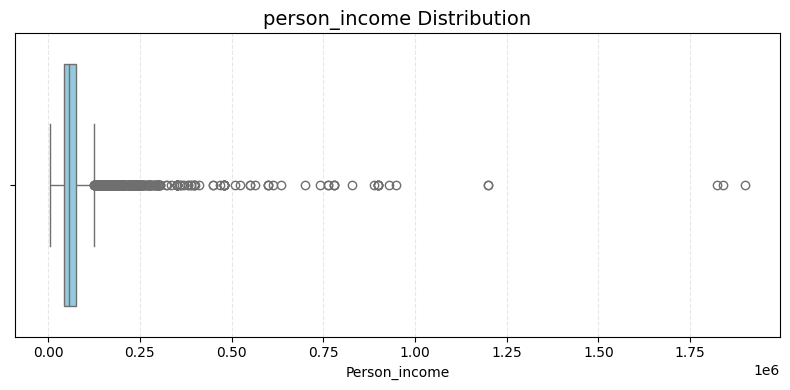

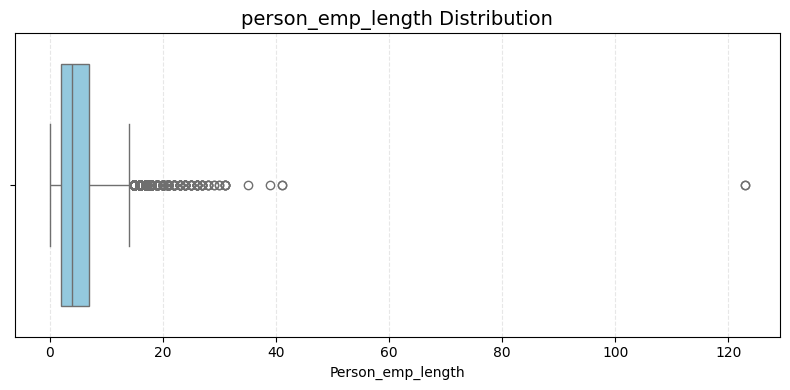

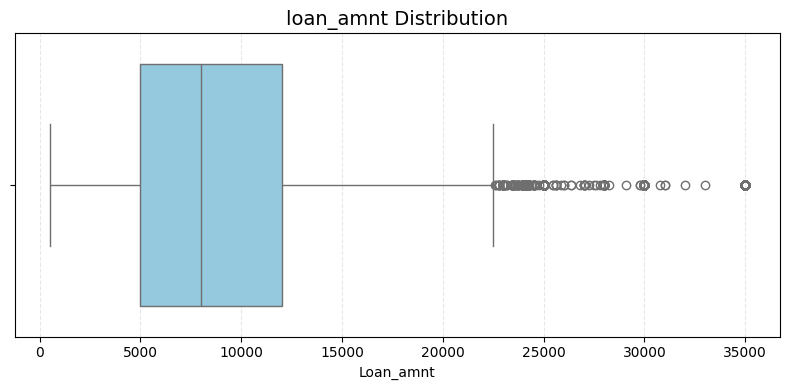

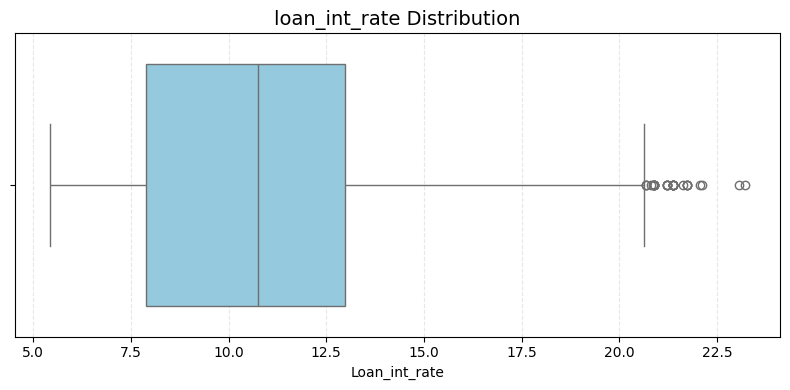

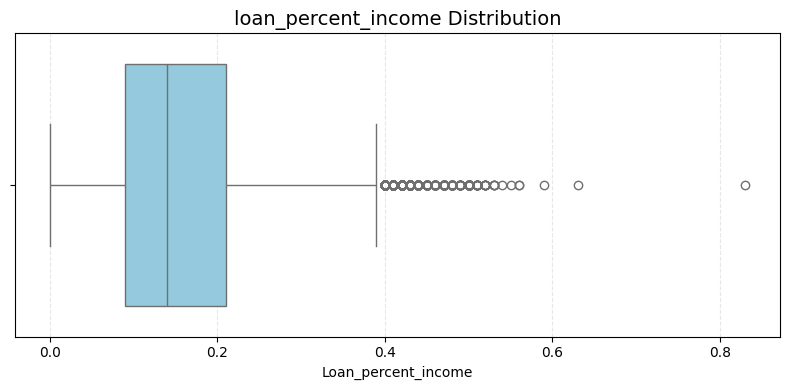

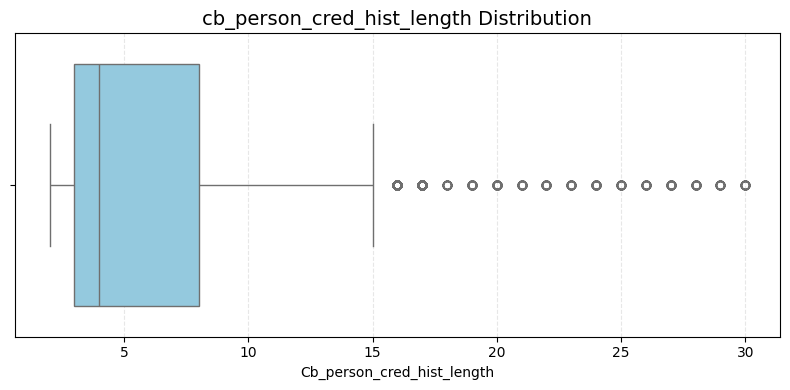

In [400]:
import seaborn as sns

def plot_numerical_boxplot(df, column, title=None):
    """
    Displays a clean boxplot for a numerical column in a DataFrame.
    
    Args:
        df (pd.DataFrame): The input DataFrame.
        column (str): The column name (numerical) to visualize.
        title (str, optional): Title for the plot.
    """
    if not pd.api.types.is_numeric_dtype(df[column]):
        raise ValueError(f"Column '{column}' must be numerical.")
    
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[column], color='skyblue')
    
    plt.title(title or f"{column} Distribution", fontsize=14)
    plt.xlabel(column.capitalize())
    plt.grid(axis='x', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

for col in list(df.columns):
    if df[col].dtype != object and col != 'loan_status':
        plot_numerical_boxplot(df, col, title=None)

# Outliers spotting

In [401]:
df.query('person_age > 100')

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
47336,123,36000,MORTGAGE,7.0,PERSONAL,B,6700,10.75,0.18,N,4,0


In [402]:
df.query('person_income > 500000')

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
2093,32,1200000,RENT,2.0,PERSONAL,A,10000,7.51,0.01,N,9,0
2298,37,780000,RENT,9.0,HOMEIMPROVEMENT,B,7500,12.18,0.01,N,7,0
4301,35,522000,RENT,2.0,DEBTCONSOLIDATION,A,10000,7.49,0.02,N,9,0
8151,29,600000,MORTGAGE,14.0,DEBTCONSOLIDATION,A,7000,8.49,0.01,N,8,0
11422,29,948000,OWN,11.0,PERSONAL,B,4000,11.83,0.04,N,5,0
11668,34,550000,MORTGAGE,12.0,EDUCATION,A,10400,7.43,0.02,N,10,0
12404,25,1839784,RENT,0.0,VENTURE,A,8000,8.00,0.04,N,3,0
12610,30,510000,MORTGAGE,2.0,PERSONAL,B,1800,9.01,0.04,N,9,0
12925,30,636000,MORTGAGE,2.0,DEBTCONSOLIDATION,B,20000,11.48,0.03,N,5,0
17387,22,1900000,MORTGAGE,6.0,EDUCATION,D,1500,15.62,0.00,Y,3,0


In [403]:
df.query('person_age < person_emp_length')

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
41079,28,60350,MORTGAGE,123.0,MEDICAL,D,25000,15.95,0.35,Y,6,1
49252,21,192000,MORTGAGE,123.0,VENTURE,B,20000,11.49,0.10,N,2,0


In [404]:
df = df.query('person_age < 100 & person_income < 500000 & person_age > person_emp_length')

# IQR-based outlier detection

In [405]:

for col in ['person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

# Correlation map

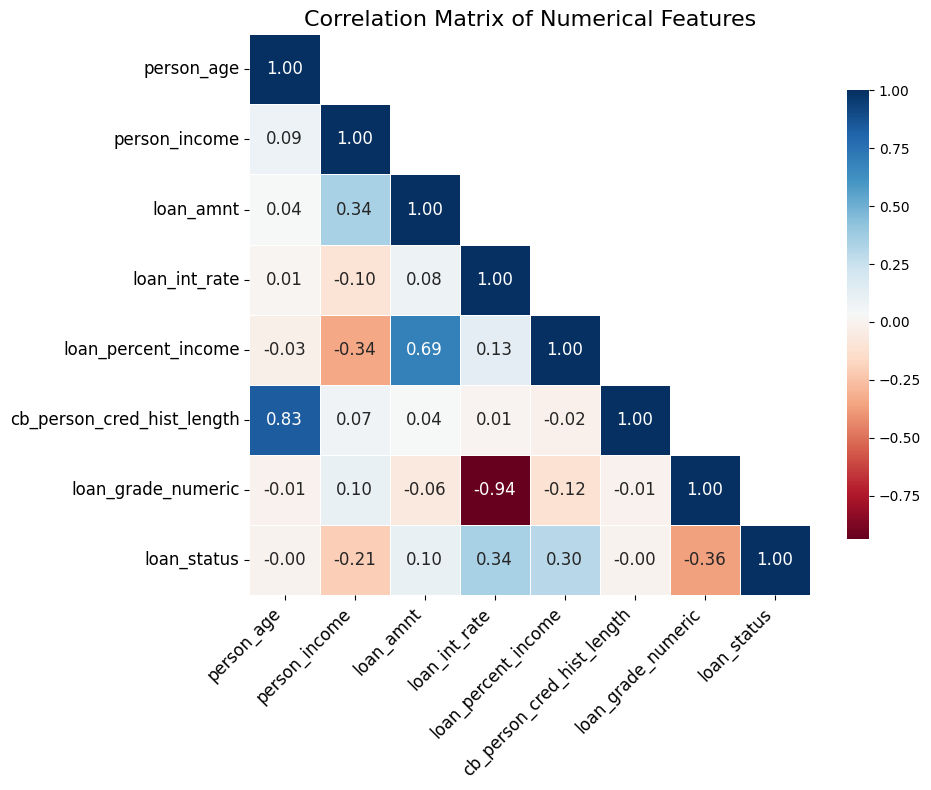

In [406]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Creates column loan_grade_numeric A->6, B->5...G->1
grade_mapping = {
    'A': 6,
    'B': 5,
    'C': 4,
    'D': 3,
    'F': 2,
    'G': 1
}

df['loan_grade_numeric'] = df['loan_grade'].map(grade_mapping)

# Create correlation matrix
numerical_features = ['person_age', 'person_income', 'loan_amnt', 'loan_int_rate',
                      'loan_percent_income', 'cb_person_cred_hist_length', 'loan_grade_numeric', 'loan_status']
corr_matrix = df[numerical_features].corr()

# Create a mask to only show lower triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), 1)

# Set up the plot
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            mask=mask,
            annot=True, 
            fmt=".2f", 
            cmap="RdBu", 
            square=True,
            linewidths=0.5,
            annot_kws={"size": 12},
            cbar_kws={"shrink": 0.8})

plt.title("Correlation Matrix of Numerical Features", fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()
plt.show()


# Dimension reduction

In [ ]:
# the loan grade is -94% correlated with the loan interest rate so we remove the grade an keep interst rate (more precision since it is float)
df = df.drop(['loan_grade','loan_grade_numeric'], axis = 1)

# Maybe remove loan history length since it is 85% correlated with age ?

In [408]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_amnt', 'loan_int_rate',
       'loan_percent_income', 'cb_person_default_on_file',
       'cb_person_cred_hist_length', 'loan_status'],
      dtype='object')

# Encoding

In [409]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Identification des données numériques et catégorielles (pas de données ordinales car loan grade a été retiré)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols = num_cols.drop('loan_status')
cat_cols = ['loan_intent','cb_person_default_on_file','person_home_ownership']

# Normalisation des données numériques
num_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# One-hot encoding pour les données catégorielles
ohe_pipeline = Pipeline(steps=[
    ('ohe', OneHotEncoder(handle_unknown='error', sparse_output=False))
])

#Définition du transformeur
col_trans = ColumnTransformer(transformers=[
    ('num_p', num_pipeline, num_cols), 
    ('ohe_p', ohe_pipeline, cat_cols)
    ],
    remainder='passthrough', # Conserve les colonnes non spécifiées
    n_jobs=-1) # Accélère le traitement avec plusieurs cœurs

#Définition d'un pipeline global qui intègre toutes les transformations définies sur les colonnes
pipeline = Pipeline(steps=[
    ('preprocessing', col_trans)
])

num_cols

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length'],
      dtype='object')

# Models training and evaluation

In [410]:
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,37,35000,RENT,0.0,EDUCATION,6000,11.49,0.17,N,14,0
1,22,56000,OWN,6.0,MEDICAL,4000,13.35,0.07,N,2,0
2,29,28800,OWN,8.0,PERSONAL,6000,8.90,0.21,N,10,0
3,30,70000,RENT,14.0,VENTURE,12000,11.11,0.17,N,5,0
4,22,60000,RENT,2.0,MEDICAL,6000,6.92,0.10,N,3,0
...,...,...,...,...,...,...,...,...,...,...,...
58639,22,70000,RENT,6.0,DEBTCONSOLIDATION,10000,7.29,0.14,N,4,0
58641,28,28800,RENT,0.0,MEDICAL,10000,12.73,0.35,N,8,1
58642,23,44000,RENT,7.0,EDUCATION,6800,16.00,0.15,N,2,1
58643,22,30000,RENT,2.0,EDUCATION,5000,8.90,0.17,N,3,0


In [411]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Séparation des données d'entraînement
X = df.drop('loan_status', axis=1) # les caractéristiques (features)
y = df['loan_status'] # la variable cible

In [412]:
# Application du prétraitement défini dans le pipeline global aux données
X_preprocessed = pipeline.fit_transform(X)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
#X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.2, random_state=25)

def evaluate_model_visual(model, X, y, kf):
    acc_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []

    all_y_true = []
    all_y_pred = []

    fold = 1

    for train_index, test_index in kf.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc_scores.append(accuracy_score(y_test, y_pred))
        precision_scores.append(precision_score(y_test, y_pred))
        recall_scores.append(recall_score(y_test, y_pred))
        f1_scores.append(f1_score(y_test, y_pred))

        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred)

        fold += 1

    # Plot Accuracy per fold
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, kf.n_splits + 1), acc_scores, marker='o')
    plt.title("Accuracy per Fold")
    plt.xlabel("Fold")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1)
    plt.grid(True)

    # Combined Confusion Matrix
    plt.subplot(1, 2, 2)
    cm = confusion_matrix(all_y_true, all_y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix (All Folds Combined)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    # Bar plot of average metrics
    plt.figure(figsize=(6, 4))
    metrics = {
        'Accuracy': np.mean(acc_scores),
        'Precision': np.mean(precision_scores),
        'Recall': np.mean(recall_scores),
        'F1 Score': np.mean(f1_scores),
    }
    sns.barplot(x=list(metrics.keys()), y=list(metrics.values()))
    plt.ylim(0, 1)
    plt.title("Average Metrics Across Folds")
    plt.show()

    return metrics

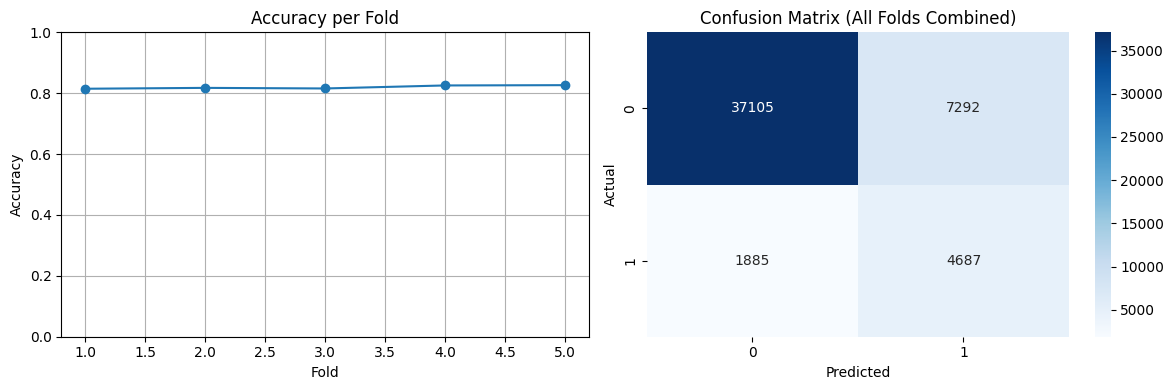

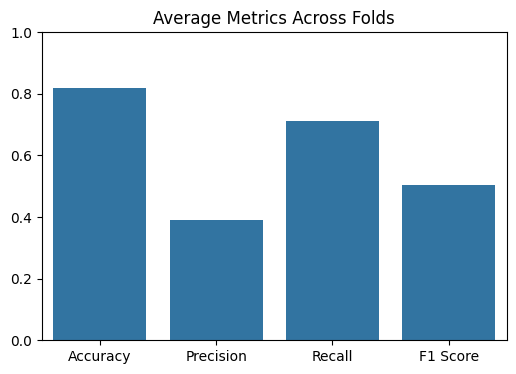

{'Accuracy': np.float64(0.8199495085250967),
 'Precision': np.float64(0.39134398944606064),
 'Recall': np.float64(0.7130196393174822),
 'F1 Score': np.float64(0.5052282749084134)}

In [413]:
nb = GaussianNB()
evaluate_model_visual(nb, X_preprocessed, y, kf)

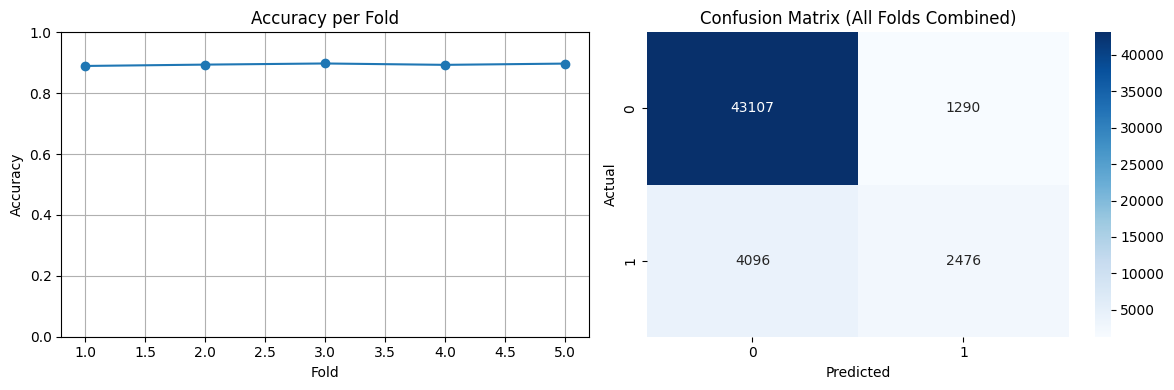

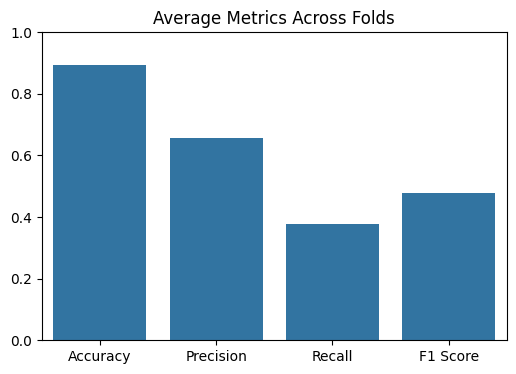

{'Accuracy': np.float64(0.8943279827829848),
 'Precision': np.float64(0.6573855667955224),
 'Recall': np.float64(0.37694095797711996),
 'F1 Score': np.float64(0.47899505608956694)}

In [414]:
lda = LinearDiscriminantAnalysis()
evaluate_model_visual(lda, X_preprocessed, y, kf)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


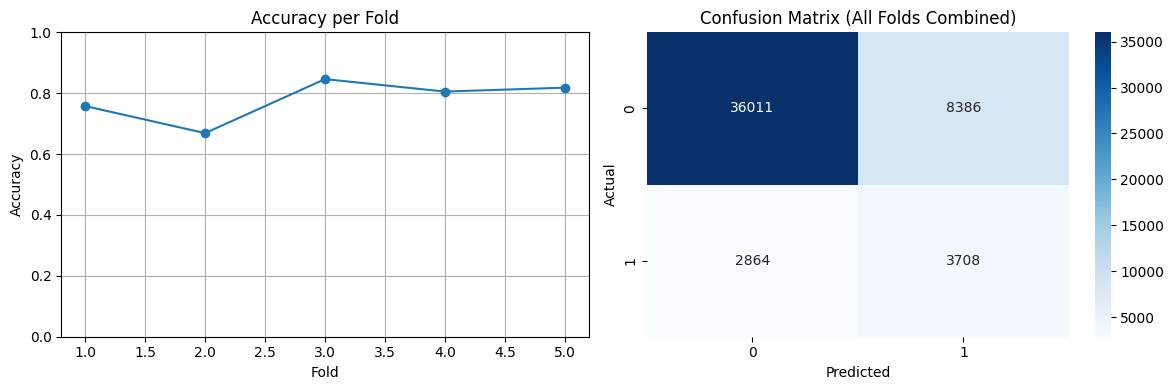

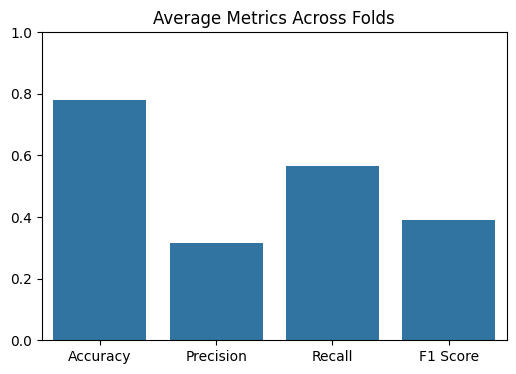

{'Accuracy': np.float64(0.7792783639116051),
 'Precision': np.float64(0.316821063732904),
 'Recall': np.float64(0.5646507282565734),
 'F1 Score': np.float64(0.39084815553869323)}

In [415]:
qda = QuadraticDiscriminantAnalysis()
evaluate_model_visual(qda, X_preprocessed, y, kf)

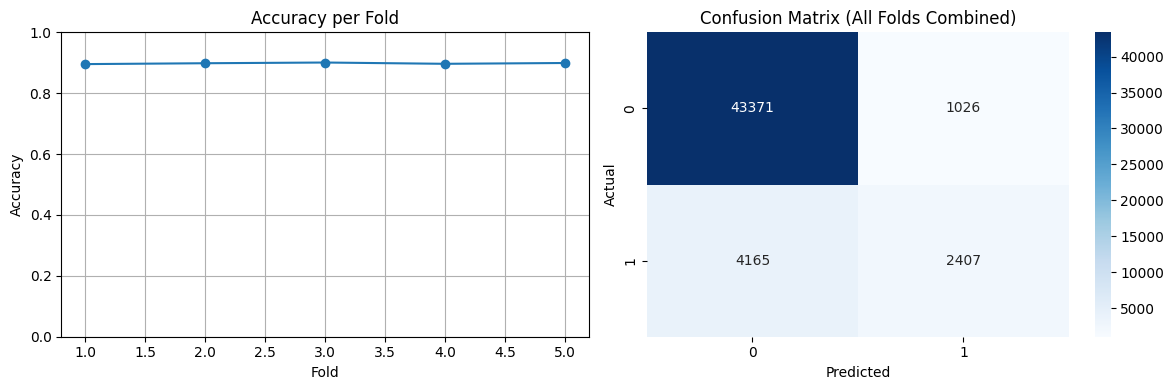

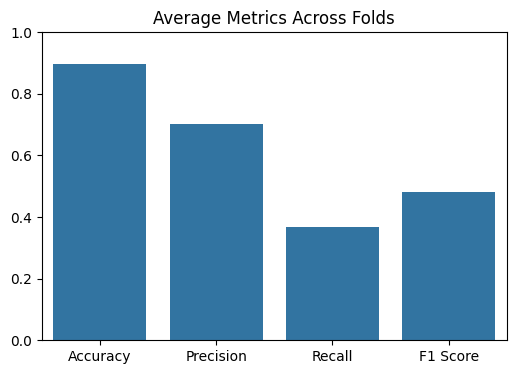

{'Accuracy': np.float64(0.898153801149296),
 'Precision': np.float64(0.7011627124465843),
 'Recall': np.float64(0.3663018980472711),
 'F1 Score': np.float64(0.4811222517535983)}

In [416]:
log_reg = LogisticRegression(max_iter=10000)
evaluate_model_visual(log_reg, X_preprocessed, y, kf)

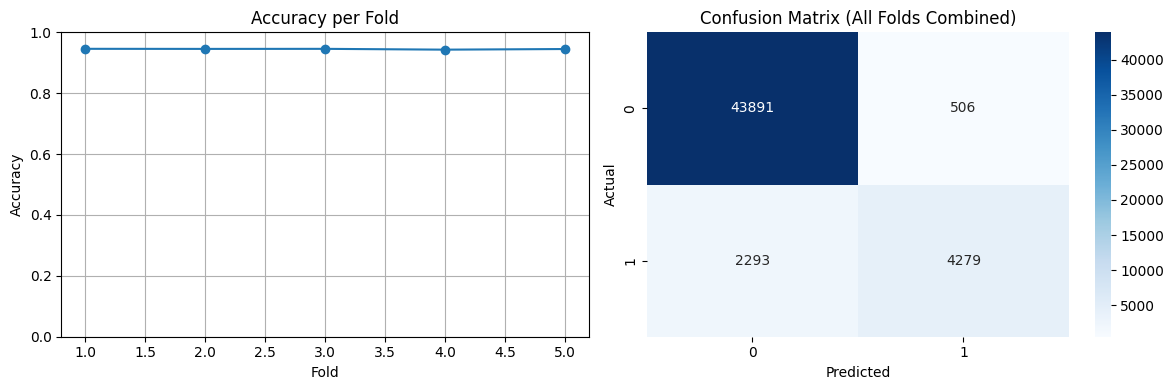

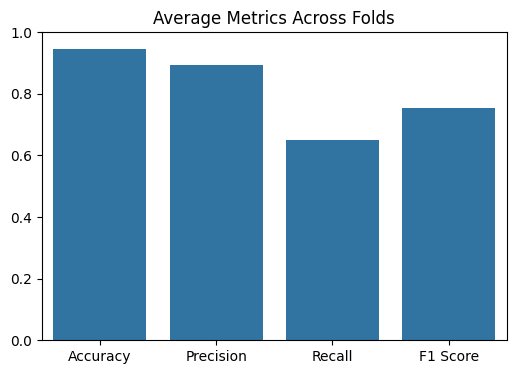

{'Accuracy': np.float64(0.9450842683626067),
 'Precision': np.float64(0.8942551428072691),
 'Recall': np.float64(0.6510880271874555),
 'F1 Score': np.float64(0.753416492967405)}

In [417]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
evaluate_model_visual(rf, X_preprocessed, y, kf)

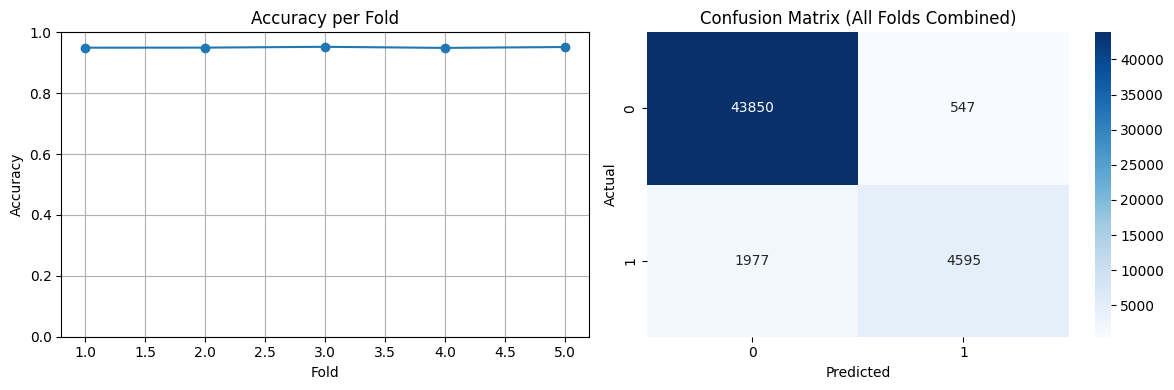

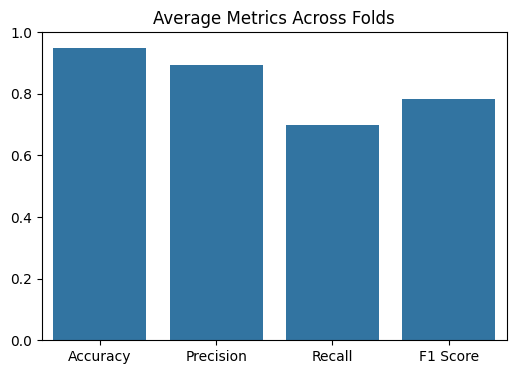

{'Accuracy': np.float64(0.9504797279101529),
 'Precision': np.float64(0.8935364769107779),
 'Recall': np.float64(0.6992759969269858),
 'F1 Score': np.float64(0.7845168650087954)}

In [ ]:
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
evaluate_model_visual(gb, X_preprocessed, y, kf)

# Kaggle submission

In [ ]:
test_raw = pd.read_csv("../data/test.csv")
test = test_raw.drop(['id','loan_grade'], axis=1)
test = test.reindex(columns=X.columns, fill_value=0)

test_preprocessed = pipeline.fit_transform(test)

predictions = gb.predict(test_preprocessed)


,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,58645,23,69000,RENT,3.0,HOMEIMPROVEMENT,F,25000,15.76,0.36,N,2
1,58646,26,96000,MORTGAGE,6.0,PERSONAL,C,10000,12.68,0.10,Y,4
2,58647,26,30000,RENT,5.0,VENTURE,E,4000,17.19,0.13,Y,2
3,58648,33,50000,RENT,4.0,DEBTCONSOLIDATION,A,7000,8.90,0.14,N,7
4,58649,26,102000,MORTGAGE,8.0,HOMEIMPROVEMENT,D,15000,16.32,0.15,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
39093,97738,22,31200,MORTGAGE,2.0,DEBTCONSOLIDATION,B,3000,10.37,0.10,N,4
39094,97739,22,48000,MORTGAGE,6.0,EDUCATION,A,7000,6.03,0.15,N,3
39095,97740,51,60000,MORTGAGE,0.0,PERSONAL,A,15000,7.51,0.25,N,25
39096,97741,22,36000,MORTGAGE,4.0,PERSONAL,D,14000,15.62,0.39,Y,4


In [420]:
submission = pd.DataFrame({
    "id": test_raw["id"],  # or whichever ID column is used
    "loan_status": predictions
})

submission.to_csv("../submission.csv", index=False)